In [ ]:

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


# download the dataset
path = kagglehub.dataset_download("chitwanmanchanda/fraudulent-transactions-data")
print(path)

df = pd.read_csv(path + "/Fraud.csv")
df.head()

100%|██████████| 178M/178M [00:01<00:00, 101MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/chitwanmanchanda/fraudulent-transactions-data/versions/1


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [ ]:
# size of dataset
print(df.shape)

# info and data types
print(df.info())

# Checking for missing values
print(df.isnull().sum())

(6362620, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB
None
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [ ]:
# some basic stats
print(df.describe())

               step        amount  oldbalanceOrg  newbalanceOrig  \
count  6.362620e+06  6.362620e+06   6.362620e+06    6.362620e+06   
mean   2.433972e+02  1.798619e+05   8.338831e+05    8.551137e+05   
std    1.423320e+02  6.038582e+05   2.888243e+06    2.924049e+06   
min    1.000000e+00  0.000000e+00   0.000000e+00    0.000000e+00   
25%    1.560000e+02  1.338957e+04   0.000000e+00    0.000000e+00   
50%    2.390000e+02  7.487194e+04   1.420800e+04    0.000000e+00   
75%    3.350000e+02  2.087215e+05   1.073152e+05    1.442584e+05   
max    7.430000e+02  9.244552e+07   5.958504e+07    4.958504e+07   

       oldbalanceDest  newbalanceDest       isFraud  isFlaggedFraud  
count    6.362620e+06    6.362620e+06  6.362620e+06    6.362620e+06  
mean     1.100702e+06    1.224996e+06  1.290820e-03    2.514687e-06  
std      3.399180e+06    3.674129e+06  3.590480e-02    1.585775e-03  
min      0.000000e+00    0.000000e+00  0.000000e+00    0.000000e+00  
25%      0.000000e+00    0.000000e+00

In [ ]:
# how many fraud vs not fraud
df['isFraud'].value_counts()

,count
isFraud,
0,6354407
1,8213


In [ ]:
# percentage of fraud
fraud_percentage = df['isFraud'].mean()*100
print(fraud_percentage)

0.12908204481801522


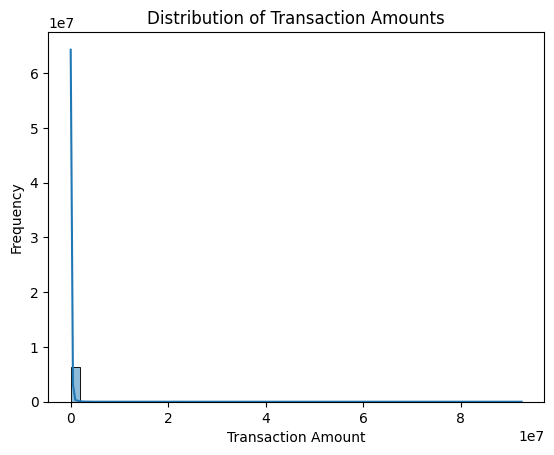

In [ ]:
## Visualizations

# amount distribution
sns.histplot(df['amount'], bins=50, kde=True)
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()

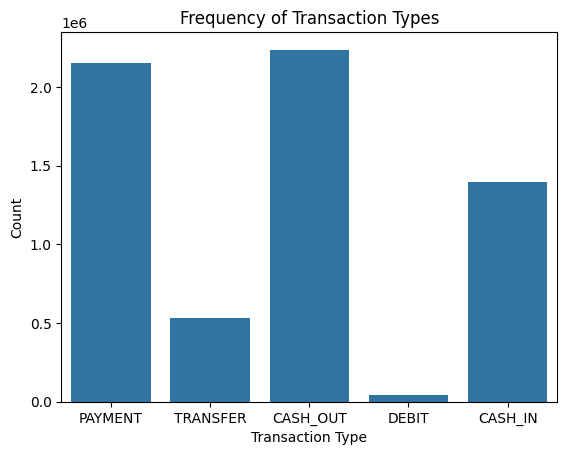

In [ ]:
# transaction types
sns.countplot(x='type', data=df)
plt.title("Frequency of Transaction Types")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

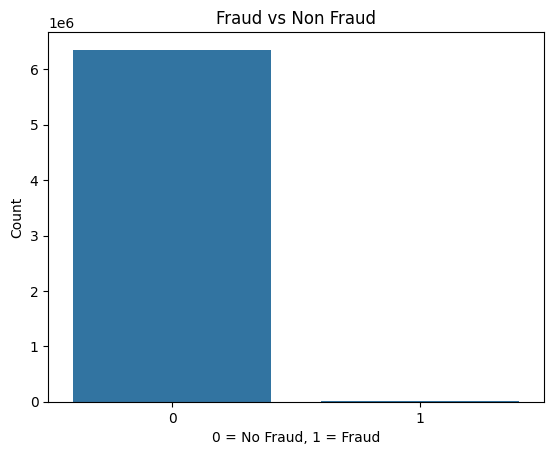

In [ ]:
# fraud vs non fraud
sns.countplot(x='isFraud', data=df)
plt.title("Fraud vs Non Fraud")
plt.xlabel("0 = No Fraud, 1 = Fraud")
plt.ylabel("Count")
plt.show()

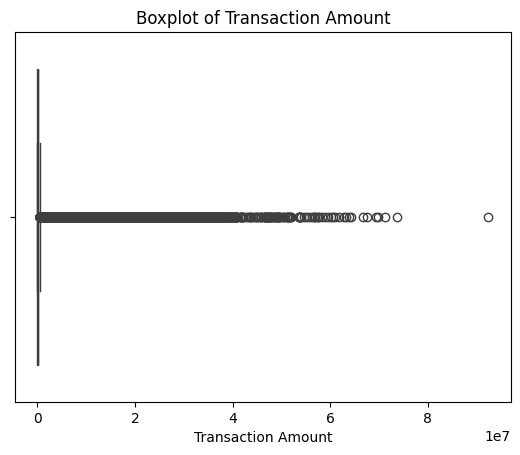

In [ ]:
# boxplot for outliers
sns.boxplot(x=df['amount'])
plt.title("Boxplot of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.show()

In [ ]:
# dropping account name columns
df = df.drop(columns=['nameOrig', 'nameDest'])

print(df.columns)


Index(['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
       'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud'],
      dtype='object')


In [ ]:
# changing transaction type into numbers
from sklearn.preprocessing import LabelEncoder

df['type'] = LabelEncoder().fit_transform(df['type'])


X = df.drop(columns=['isFraud'])
y = df['isFraud']

# checking columns
print(X.columns)
print(y.name)

Index(['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
       'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud'],
      dtype='object')
isFraud


In [ ]:
from sklearn.model_selection import train_test_split

# splitting data 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# checking
print(X_train.shape)
print(X_test.shape)

(4453834, 8)
(1908786, 8)


In [ ]:
from sklearn.linear_model import LogisticRegression

# creating the model
# increased iterations so model can finish training
model = LogisticRegression(max_iter=1000)

# training the model
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# predictions
y_pred = model.predict(X_test)

# check first 10 predictions
y_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1906052     270]
 [   1492     972]]


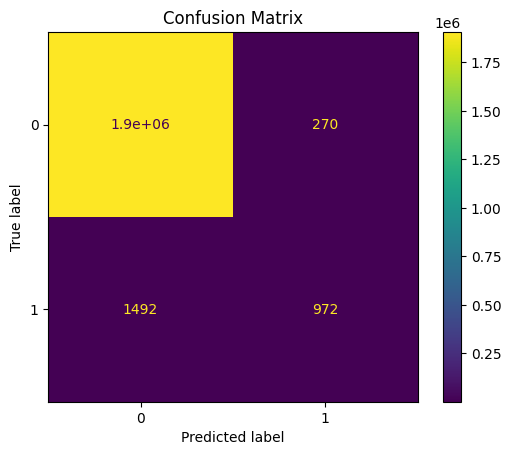

In [ ]:
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.9990769001868203
Precision: 0.782608695652174
Recall: 0.3944805194805195


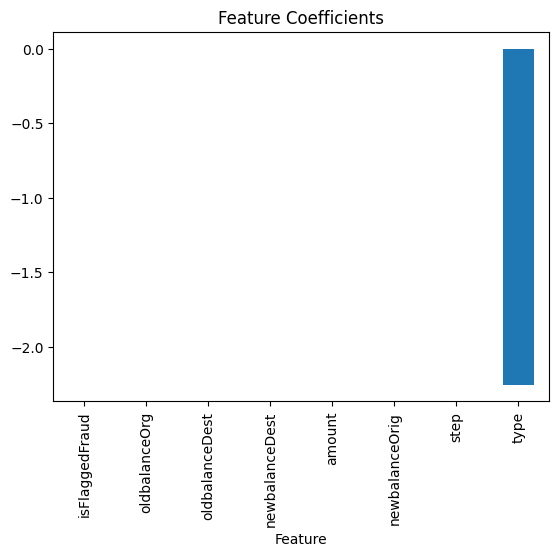

In [ ]:
# getting model coefficients

coef = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}


# Graph coefficient (Highest to lowest)

coef = coef.sort_values(by='Coefficient', ascending=False)


coef.plot(kind='bar', x='Feature', y='Coefficient', legend=False)
plt.title("Feature Coefficients")
plt.show()